<a href="https://colab.research.google.com/github/DavitIshkhanyan/named-entity-recognition/blob/main/CoNLL2003_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
!pip install datasets -q

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("lhoestq/conll2003")

print("Overall Dataset Structure:")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/3.67k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Overall Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


In [ ]:
sample = dataset['train'][0]

print("1 Tokens:", sample['tokens'])

1 Tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']


In [ ]:
tags = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
print(tags)

print("NER Tag Dictionary (ID -> Tag): ")
for i, tag in enumerate(tags):
  print(f"ID {i}, {tag}")


['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
NER Tag Dictionary (ID -> Tag): 
ID 0, O
ID 1, B-PER
ID 2, I-PER
ID 3, B-ORG
ID 4, I-ORG
ID 5, B-LOC
ID 6, I-LOC
ID 7, B-MISC
ID 8, I-MISC


In [ ]:
words = dataset['train'][0]['tokens']

tag_ids = dataset['train'][0]['ner_tags']

word_tag_pairs = []
for word, tag_id in zip(words, tag_ids):
    real_tag_name = tags[tag_id]
    word_tag_pairs.append((word, real_tag_name))


df = pd.DataFrame(word_tag_pairs, columns=['Token (Բառ)', 'NER Tag (Պիտակ)'])

print("\n--- Training Sentence Example ---")
print(df)


--- Training Sentence Example ---
  Token (Բառ) NER Tag (Պիտակ)
0          EU           B-ORG
1     rejects               O
2      German          B-MISC
3        call               O
4          to               O
5     boycott               O
6     British          B-MISC
7        lamb               O
8           .               O


Minimum sentence length: 1 words
Average sentence length: 14.50 words
Maximum sentence length: 113 words


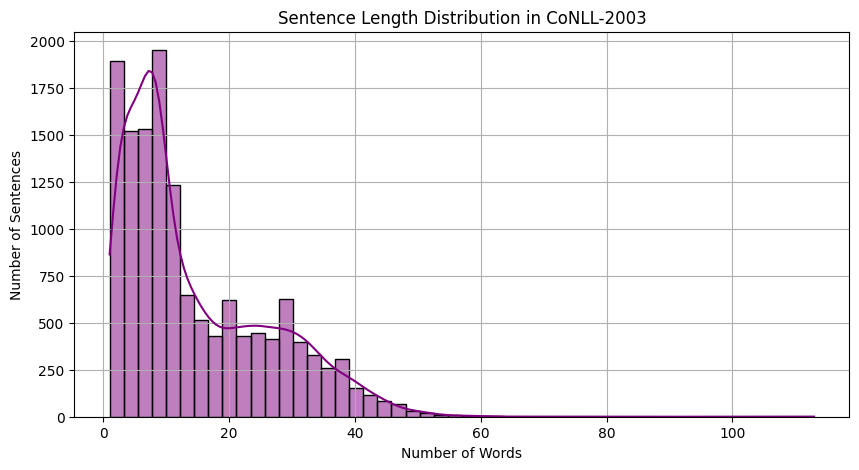

In [ ]:
train_lengths = [len(x['tokens']) for x in dataset['train']]

print(f"Minimum sentence length: {min(train_lengths)} words")
print(f"Average sentence length: {sum(train_lengths)/len(train_lengths):.2f} words")
print(f"Maximum sentence length: {max(train_lengths)} words")

plt.figure(figsize=(10, 5))

sns.histplot(train_lengths, bins=50, kde=True, color='purple')

plt.title("Sentence Length Distribution in CoNLL-2003")
plt.xlabel("Number of Words")
plt.ylabel("Number of Sentences")
plt.grid(True)

plt.show()

/tmp/ipykernel_2656/2015743445.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Label', data=df_counts, palette='magma')


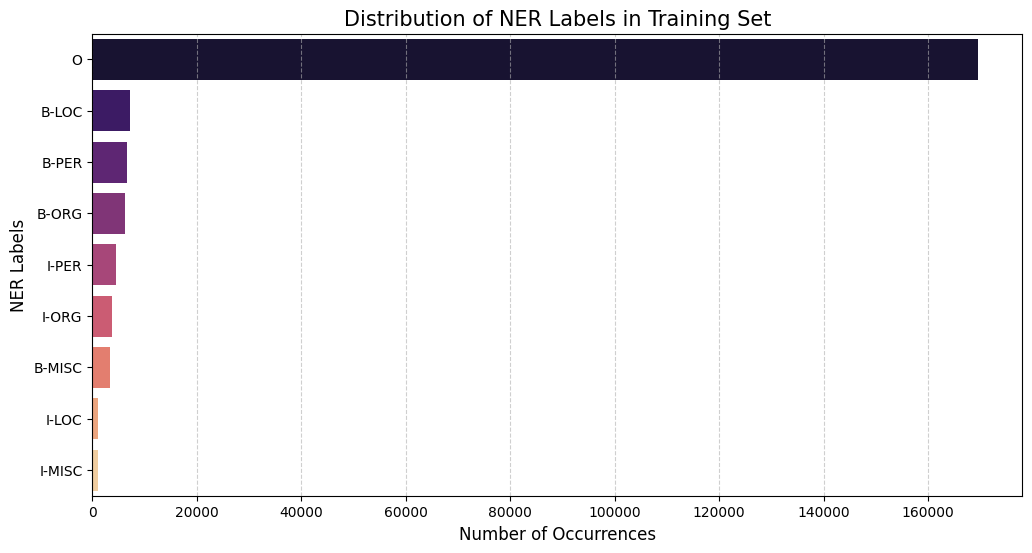

Exact counts for each label:
 Label  Count
     O 169578
 B-LOC   7140
 B-PER   6600
 B-ORG   6321
 I-PER   4528
 I-ORG   3704
B-MISC   3438
 I-LOC   1157
I-MISC   1155


In [ ]:
all_label_ids = []
for sentence_labels in dataset['train']['ner_tags']:
    all_label_ids.extend(sentence_labels)

all_label_names = [tags[i] for i in all_label_ids]

label_counts = Counter(all_label_names)

df_counts = pd.DataFrame(label_counts.items(), columns=['Label', 'Count'])
df_counts = df_counts.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Label', data=df_counts, palette='magma')

plt.title('Distribution of NER Labels in Training Set', fontsize=15)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('NER Labels', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print("Exact counts for each label:")
print(df_counts.to_string(index=False))

In [ ]:
sample_indices = [0, 10, 33]

for idx in sample_indices:
    words = dataset['train'][idx]['tokens']
    tag_ids = dataset['train'][idx]['ner_tags']

    word_tag_pairs = []
    for word, tag_id in zip(words, tag_ids):
        df_sample = pd.DataFrame([(word, tags[tag_id])], columns=['Token', 'NER Tag'])

        full_sentence = " ".join(words)
        print(f"Sentence: {full_sentence}")
        print("-" * 50)

        print(df_sample.T)
        print("=" * 60, "\n")

Sentence: EU rejects German call to boycott British lamb .
--------------------------------------------------
             0
Token       EU
NER Tag  B-ORG

Sentence: EU rejects German call to boycott British lamb .
--------------------------------------------------
               0
Token    rejects
NER Tag        O

Sentence: EU rejects German call to boycott British lamb .
--------------------------------------------------
              0
Token    German
NER Tag  B-MISC

Sentence: EU rejects German call to boycott British lamb .
--------------------------------------------------
            0
Token    call
NER Tag     O

Sentence: EU rejects German call to boycott British lamb .
--------------------------------------------------
          0
Token    to
NER Tag   O

Sentence: EU rejects German call to boycott British lamb .
--------------------------------------------------
               0
Token    boycott
NER Tag        O

Sentence: EU rejects German call to boycott British lamb .
--

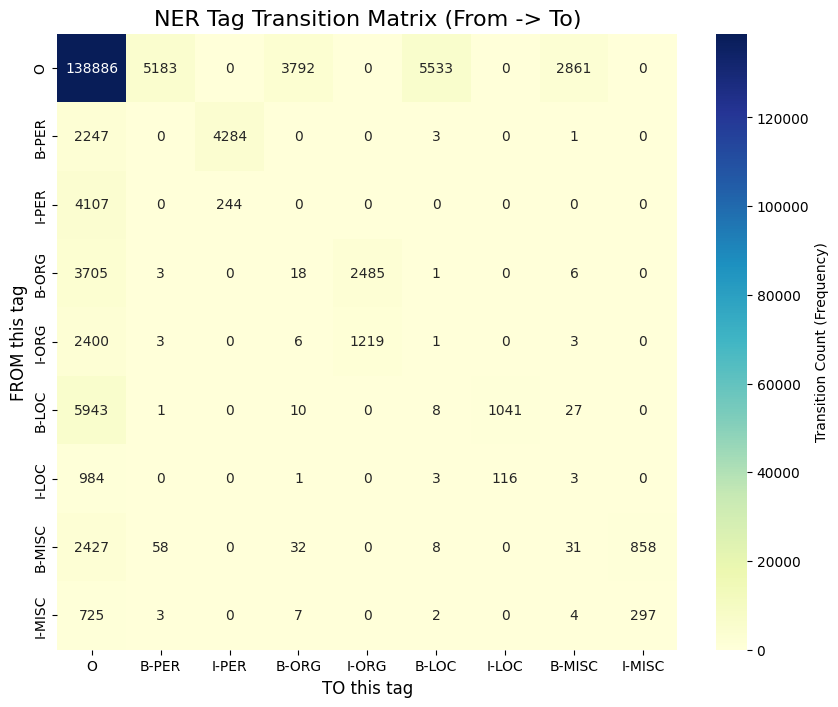

In [ ]:
num_tags = len(tags)

transition_matrix = np.zeros((num_tags, num_tags))

for labels in dataset['train']['ner_tags']:
    for i in range(len(labels) - 1):
        current_tag = labels[i]
        next_tag = labels[i+1]
        transition_matrix[current_tag, next_tag] += 1

df_transitions = pd.DataFrame(transition_matrix, index=tags, columns=tags)

plt.figure(figsize=(10, 8))

sns.heatmap(df_transitions, annot=True, fmt="g", cmap="YlGnBu",
            cbar_kws={'label': 'Transition Count (Frequency)'})

plt.title("NER Tag Transition Matrix (From -> To)", fontsize=16)
plt.ylabel("FROM this tag", fontsize=12)
plt.xlabel("TO this tag", fontsize=12)
plt.show()

In [ ]:
splits = ['train', 'validation', 'test']

print("--- Data Quality and Integrity Check ---\n")

for split in splits:
    empty_sentences = 0
    mismatched_lengths = 0
    empty_tokens = 0
    total_sentences = len(dataset[split])

    for tokens, tags in zip(dataset[split]['tokens'], dataset[split]['ner_tags']):

        if len(tokens) == 0:
            empty_sentences += 1

        if len(tokens) != len(tags):
            mismatched_lengths += 1

        for token in tokens:
            if not isinstance(token, str) or token.strip() == "":
                empty_tokens += 1

    print(f"Results for '{split.upper()}' split ({total_sentences} sentences):")
    print(f"  - Empty sentences (0 words)      : {empty_sentences}")
    print(f"  - Mismatched tokens/tags length  : {mismatched_lengths}")
    print(f"  - Empty or purely whitespace words: {empty_tokens}")
    print("-" * 45)

--- Data Quality and Integrity Check ---

Results for 'TRAIN' split (14041 sentences):
  - Empty sentences (0 words)      : 0
  - Mismatched tokens/tags length  : 0
  - Empty or purely whitespace words: 0
---------------------------------------------
Results for 'VALIDATION' split (3250 sentences):
  - Empty sentences (0 words)      : 0
  - Mismatched tokens/tags length  : 0
  - Empty or purely whitespace words: 0
---------------------------------------------
Results for 'TEST' split (3453 sentences):
  - Empty sentences (0 words)      : 0
  - Mismatched tokens/tags length  : 0
  - Empty or purely whitespace words: 0
---------------------------------------------
